In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "30"
os.environ["MKL_NUM_THREADS"] = "30"
os.environ["OPENBLAS_NUM_THREADS"] = "30"
os.environ["NUMEXPR_NUM_THREADS"] = "30"
os.environ["VECLIB_MAXIMUM_THREADS"] = "30"
# (Optional) Verify it worked
!echo "OMP_NUM_THREADS is set to $OMP_NUM_THREADS"



OMP_NUM_THREADS is set to 30


In [3]:
%%time
import anndata as ad             
import matplotlib.pyplot as plt 
import metacells as mc           
import numpy as np               
import pandas as pd             
import seaborn as sb             
import scipy.sparse as sp        
import shutil                    
from math import hypot           
import metacells
import scipy
from scipy import io
import sys
import scanpy as sc 


/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/umap/distances.py:1053: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/umap/distances.py:1061: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/data/leuven/332/vsc33224/mi

CPU times: user 9.77 s, sys: 10.7 s, total: 20.5 s
Wall time: 14.2 s


In [4]:
import SEACells_resume
import SEACells_resume as SEACells #had to modify seacells to run a few iterations at a time (otherwise crashes when trying to run all iterations at once - for smaller datasets should be ok)
import SEACells_resume.cpu as cpu  #modified module


In [5]:

combined_adata = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_HVGs_cleaned.h5ad')


In [12]:
# they recommend one metacell for every 300 real cells
n_SEACells = int(np.floor(combined_adata.obs.shape[0] / 750))
print(n_SEACells)

build_kernel_on = 'X_pca_harmony' 

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells
waypoint_proportion = 0.9 

# set up the model
model = SEACells.core.SEACells(combined_adata,
                  build_kernel_on=build_kernel_on,
                  n_SEACells=n_SEACells,
                  n_waypoint_eigs=n_waypoint_eigs,
                  convergence_epsilon = 1e-5, 
                  use_sparse=True)


model.construct_kernel_matrix()
M = model.kernel_matrix

model.initialize_archetypes()


1154
Welcome to SEACells!
Computing kNN graph using scanpy NN ...


/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


Computing radius for adaptive bandwidth kernel...


  0%|          | 0/865642 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/865642 [00:00<?, ?it/s]

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceed

In [16]:
# # Initialize archetypes
# model.initialize_archetypes()

In [15]:
# save the model to a pickle file
with open('model_dataset_noOutlier_tmp.pkl', 'wb') as f:
    pickle.dump(model, f)
    
# Trick pickle into thinking SEACells.cpu exists
sys.modules['SEACells.cpu'] = cpu

In [14]:
# Open the pickled model
with open('model_dataset_noOutlier_tmp.pkl', 'rb') as f:
    model = pickle.load(f)

In [4]:
model.fit(max_iter=2, min_iter=0, resume=False) #run two iterations at a time so it doesn't crazh

# save the model to a pickle file
with open('model_resume_tmp_1.pkl', 'wb') as f:
    pickle.dump(model, f)

In [5]:
import pickle

# Open the file containing the pickled object in binary mode
with open('model_dataset_noOutlier_tmp.pkl', 'rb') as f:
    # Load the pickled object from the file
    model = pickle.load(f)


In [ ]:
model.fit(max_iter=2, min_iter=0, resume=False) 

In [9]:
# rerun as many times as neded until convergence

In [ ]:
with open('model_resume_tmp_24.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('model_resume_tmp_24.pkl', 'rb') as f:
    model = pickle.load(f)


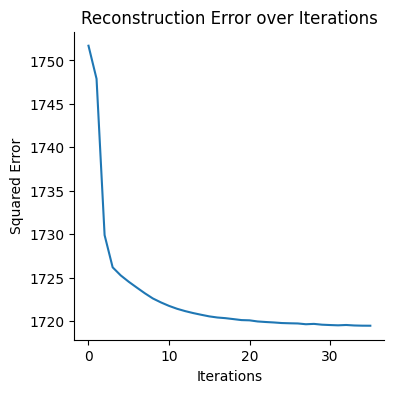

In [10]:
model.plot_convergence()


In [9]:
combined_adata.obs['SEACell'] = list(model.get_hard_assignments()['SEACell'])

In [10]:
model.get_hard_assignments()['SEACell']


index
AAACGAAGTAGAGGAA-1-0      SEACell-512
AAACGAATCTAAGAAG-1-0      SEACell-528
AAACGCTCATCTAACG-1-0      SEACell-987
AAACGCTGTGCATCTA-1-0      SEACell-405
AAACGCTTCGGTTCAA-1-0      SEACell-954
                             ...     
TTGATGGAGATTAGAC-16-14    SEACell-677
TTGTTTGCAGTCAGAG-16-14    SEACell-460
TTTCCTCAGCGGGTAT-16-14    SEACell-242
TTTGGTTCACGACAAG-16-14    SEACell-151
TTTGGTTTCGCACTCT-16-14    SEACell-855
Name: SEACell, Length: 865642, dtype: object

In [6]:
combined_adata_proc = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_HVGs_cleaned.h5ad')

In [14]:
combined_adata.obsm['X_umap'] = combined_adata_proc.obsm['X_umap']

In [14]:
combined_adata.write_h5ad('./TMP2_v2_combined_PFC_L23_h5ad_20251121_HVGs_cleaned_seacells.h5ad')


In [5]:
combined_adata_raw = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_raw_cleaned.h5ad')

combined_adata_raw.obs['SEACell']= list(combined_adata.obs['SEACell'])
combined_adata_raw.layers['counts'] = combined_adata_raw.X.copy()
combined_adata_raw.obsm['X_umap']  = combined_adata.obsm['X_umap'].copy()

In [ ]:
#summarize raw counts 
SEACell_ad = SEACells.core.summarize_by_SEACell(combined_adata_raw, SEACells_label='SEACell', summarize_layer='counts')
SEACell_ad

In [80]:
SEACell_ad.obs['total_cells'] = SEACell_ad.obs['No_SEAAD_cells']+SEACell_ad.obs['No_101010_cells']+SEACell_ad.obs['No_Gaz_cells']+SEACell_ad.obs['No_Mathys_cells']

SEACell_ad = SEACell_ad[SEACell_ad.obs['total_cells'] > 250].copy()
SEACell_ad = SEACell_ad[SEACell_ad.obs['# Distinct Datasets'] > 1].copy()
SEACell_ad = SEACell_ad[SEACell_ad.obs['# Distinct Donors'] > 5].copy()

In [12]:
# normalize to 5000 CPM and then aggregate 

adata_norm = combined_adata_raw.copy()

# Normalize to 50K counts per cell
sc.pp.normalize_total(adata_norm, target_sum=50000)

print(f"After normalization - sum per cell should be ~50K:")
print(f"Mean total counts per cell: {adata_norm.X.sum(axis=1).mean():.1f}")

#  pseudobulk by summing normalized values per metacell
df = pd.DataFrame(
    adata_norm.X.toarray() if hasattr(adata_norm.X, 'toarray') else adata_norm.X,
    index=adata_norm.obs_names,
    columns=adata_norm.var_names
)

# Add SEACell labels and aggregate by summing
df['SEACell'] = adata_norm.obs['SEACell'].values
pseudobulk = df.groupby('SEACell').sum()

# Calculate numb of cells per metacell 
n_cells_per_metacell = combined_adata_raw.obs.groupby('SEACell').size()

# Step 4: Create pseudobulk AnnData object
pseudobulk_adata = ad.AnnData(
    X=pseudobulk.values,
    obs=pd.DataFrame(index=pseudobulk.index),
    var=combined_adata_raw.var.copy()
)

# Add number of cells as metadata
pseudobulk_adata.obs['n_cells'] = n_cells_per_metacell.values
pseudobulk_adata.obs['log_n_cells'] = np.log(n_cells_per_metacell.values)

print(f"\nOriginal: {combined_adata_raw.shape}")
print(f"Pseudobulk: {pseudobulk_adata.shape}")
print(f"Cells per metacell - min: {n_cells_per_metacell.min()}, max: {n_cells_per_metacell.max()}")

After normalization - sum per cell should be ~50K:
Mean total counts per cell: 50000.0

Original: (865642, 13164)
Pseudobulk: (1154, 13164)
Cells per metacell - min: 40, max: 2201


In [13]:
pseudobulk_adata.write_h5ad('./TMP2_seacells_object_average_normalized_50K_20260120.h5ad')

In [10]:
# normalize to 5000 CPM and then aggregate 

# Make a copy to preserve raw data
adata_norm = combined_adata_raw.copy()

# Normalize to 50K counts per cell
sc.pp.normalize_total(adata_norm, target_sum=50000)

print(f"After normalization - sum per cell should be ~50K:")
print(f"Mean total counts per cell: {adata_norm.X.sum(axis=1).mean():.1f}")

# pseudobulk by summing normalized values per metacell
df = pd.DataFrame(
    adata_norm.X.toarray() if hasattr(adata_norm.X, 'toarray') else adata_norm.X,
    index=adata_norm.obs_names,
    columns=adata_norm.var_names
)

# Add SEACell labels and ggregate by taking average
df['SEACell'] = adata_norm.obs['SEACell'].values
pseudobulk = df.groupby('SEACell').mean()

# calculate number of cells per metacell 
n_cells_per_metacell = combined_adata_raw.obs.groupby('SEACell').size()

# pseudobulk AnnData object
pseudobulk_adata = ad.AnnData(
    X=pseudobulk.values,
    obs=pd.DataFrame(index=pseudobulk.index),
    var=combined_adata_raw.var.copy()
)

# Add number of cells as metadata
pseudobulk_adata.obs['n_cells'] = n_cells_per_metacell.values
pseudobulk_adata.obs['log_n_cells'] = np.log(n_cells_per_metacell.values)

print(f"\nOriginal: {combined_adata_raw.shape}")
print(f"Pseudobulk: {pseudobulk_adata.shape}")
print(f"Cells per metacell - min: {n_cells_per_metacell.min()}, max: {n_cells_per_metacell.max()}")

After normalization - sum per cell should be ~50K:
Mean total counts per cell: 50000.0

Original: (865642, 13164)
Pseudobulk: (1154, 13164)
Cells per metacell - min: 40, max: 2201


In [11]:
pseudobulk_adata.write_h5ad('./TMP2_seacells_object_average_normalized_50K_20260203.h5ad')

/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


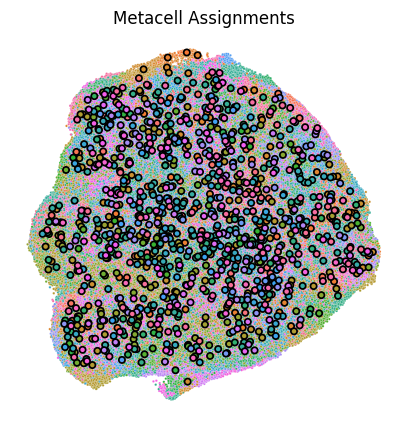

In [11]:
SEACells.plot.plot_2D(combined_adata_raw, key='X_umap', colour_metacells=True, cell_size=3)


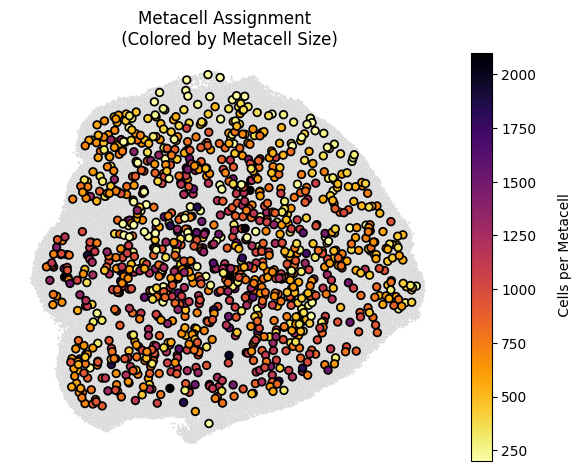

In [12]:

def plot_2D_test(
    ad,
    key="X_umap",
    colour_metacells=True,
    title="Metacell size",
    save_as=None,
    show=True,
    cmap="viridis",
    figsize=(7, 5.3),
    SEACell_size=30,
    cell_size=10,
    vmin=None,
    vmax=None,
):
    """
    Plot 2D visualization of SEACells, colored by number of cells per metacell.

    Parameters
    ----------
    ad : AnnData
        AnnData object containing SEACell labels in ad.obs["SEACell"]
    key : str
        2D embedding key in ad.obsm (e.g. "X_umap")
    colour_metacells : bool
        Whether to color SEACell centroids by size
    title : str
        Plot title
    save_as : str or None
        Path to save figure
    show : bool
        Whether to show the figure
    cmap : str
        Matplotlib continuous colormap
    figsize : tuple
        Figure size
    SEACell_size : int
        Size of metacell centroid points
    cell_size : float
        Size of individual cell points
    vmin, vmax : float or None
        Color scale limits for metacell size
    """

    # Build embedding dataframe
    umap = (
        pd.DataFrame(ad.obsm[key], index=ad.obs_names)
        .join(ad.obs["SEACell"])
    )
    umap["SEACell"] = umap["SEACell"].astype("category")

    # Compute SEACell centroids and sizes
    mc_sizes = umap["SEACell"].value_counts().rename("n_cells")

    mcs = (
        umap
        .groupby("SEACell")
        .mean()
        .join(mc_sizes)
        .reset_index()
    )

    # Set color normalization
    norm = mpl.colors.Normalize(
        vmin=vmin if vmin is not None else mcs["n_cells"].min(),
        vmax=vmax if vmax is not None else mcs["n_cells"].max(),
    )

    plt.figure(figsize=figsize)

    # Plot individual cells in grey
    sns.scatterplot(
        x=0,
        y=1,
        data=umap,
        color="lightgrey",
        s=cell_size,
        legend=None,
                        rasterized=True

    )

    # Plot SEACell centroids
    if colour_metacells:
        ax = sns.scatterplot(
            x=0,
            y=1,
            data=mcs,
            s=SEACell_size,
            hue="n_cells",
            palette=cmap,
            hue_norm=norm,
            edgecolor="black",
            linewidth=1.25,
            legend=False,
                            rasterized=True

        )

        # Add colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="\n Cells per Metacell")

    else:
        sns.scatterplot(
            x=0,
            y=1,
            data=mcs,
            s=SEACell_size,
            color="red",
            edgecolor="black",
            linewidth=1.25,
            legend=None,
                rasterized=True
        )

    plt.xlabel(f"{key}-0")
    plt.ylabel(f"{key}-1")
    plt.title(title)

    ax = plt.gca()
    ax.set_axis_off()

    if save_as is not None:
        plt.savefig(save_as, dpi=200, transparent=True)

    if show:
        plt.show()

    plt.close()

    
plot_2D_test(
    combined_adata_raw,
    key="X_umap",
    colour_metacells=True,
    cmap="inferno_r",
    cell_size=2.5,
    vmin=200,
    vmax=2100,
    title = 'Metacell Assignment \n (Colored by Metacell Size)', save_as = 'metacells_umap.pdf'
)

In [1]:
ls

ClusterMetacells_PTonMetadata_final.ipynb*
combined_L23_v2_noRefOutliers_DatasetIntegrate_4000_h5ad_20251108_seacells.h5ad
GenerateMetacells_v2_AggCounts_L23_final.ipynb*
old/


In [67]:
def plot_2D_braak(
    ad,
    key="X_umap",
    colour_metacells=True,
    title="Metacell Braak stage",
    save_as=None,
    show=True,
    cmap="viridis",
    figsize=(7, 5.3),
    SEACell_size=35,
    cell_size=10,
    vmin=None,
    vmax=None,
):
    """
    Plot 2D visualization of SEACells, colored by average Braak stage per metacell.

    Parameters
    ----------
    ad : AnnData
        AnnData object containing SEACell labels in ad.obs["SEACell"] and Braak scores in ad.obs["Braak_numeric"]
    key : str
        2D embedding key in ad.obsm (e.g. "X_umap")
    colour_metacells : bool
        Whether to color SEACell centroids by Braak stage
    title : str
        Plot title
    save_as : str or None
        Path to save figure
    show : bool
        Whether to show the figure
    cmap : str
        Matplotlib continuous colormap
    figsize : tuple
        Figure size
    SEACell_size : int
        Size of metacell centroid points
    cell_size : float
        Size of individual cell points
    vmin, vmax : float or None
        Color scale limits for average Braak stage
    """

    # Build embedding dataframe
    umap = (
        pd.DataFrame(ad.obsm[key], index=ad.obs_names)
        .join(ad.obs[["SEACell", "Braak_numeric"]])
    )
    umap["SEACell"] = umap["SEACell"].astype("category")

    # Compute SEACell centroids and average Braak
    mcs = (
        umap
        .groupby("SEACell")
        .agg({0: "mean", 1: "mean", "Braak_numeric": "mean"})
        .reset_index()
    )

    # Set color normalization
    norm = mpl.colors.Normalize(
        vmin=vmin if vmin is not None else mcs["Braak_numeric"].min(),
        vmax=vmax if vmax is not None else mcs["Braak_numeric"].max(),
    )

    plt.figure(figsize=figsize)

    # Plot individual cells in grey
    sns.scatterplot(
        x=0,
        y=1,
        data=umap,
        color="lightgrey",
        s=cell_size,
        legend=None,
        rasterized=True
    )

    # Plot SEACell centroids
    if colour_metacells:
        ax = sns.scatterplot(
            x=0,
            y=1,
            data=mcs,
            s=SEACell_size,
            hue="Braak_numeric",
            palette=cmap,
            hue_norm=norm,
            edgecolor="black",
            linewidth=1.25,
            legend=False,
            rasterized=True
        )

        # Add colorbar
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="\nMean Braak per Metacell")
    else:
        sns.scatterplot(
            x=0,
            y=1,
            data=mcs,
            s=SEACell_size,
            color="red",
            edgecolor="black",
            linewidth=1.25,
            legend=None,
            rasterized=True
        )

    plt.xlabel(f"{key}-0")
    plt.ylabel(f"{key}-1")
    plt.title(title)

    ax = plt.gca()
    ax.set_axis_off()

    if save_as is not None:
        plt.savefig(save_as, dpi=200, transparent=True)

    if show:
        plt.show()

    plt.close()


In [68]:
combined_adata_raw2.obs['SEACell'] = combined_adata_raw2.obs['SEACell_x'].copy()

In [ ]:
combined_adata_raw2 = combined_adata_raw2[combined_adata_raw2.obs['SEACell'].isin(list(SEACell_copy.obs.index))]

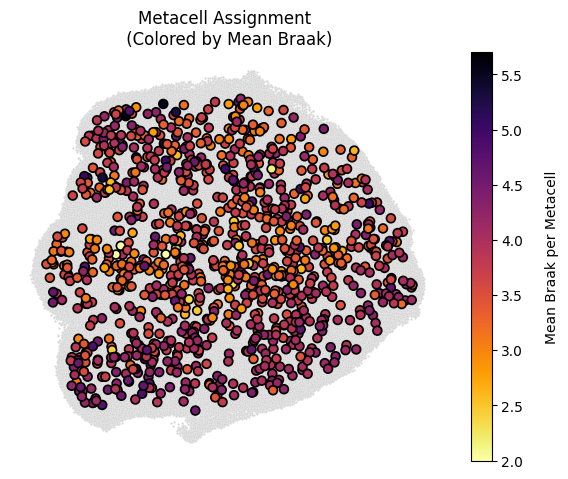

In [109]:
plot_2D_braak(
    combined_adata_raw2,
    key="X_umap",
    SEACell_size = 40,
    colour_metacells=True,
    cmap="inferno_r",
     vmax=5.7,
     vmin = 2,
    cell_size=2.5,
    title='Metacell Assignment \n (Colored by Mean Braak)', 
    save_as = 'metacells_braak_umap.pdf'
)

/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/SEACells_resume/plot.py:130: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby("SEACell").count().iloc[:, 0], bins=bins)


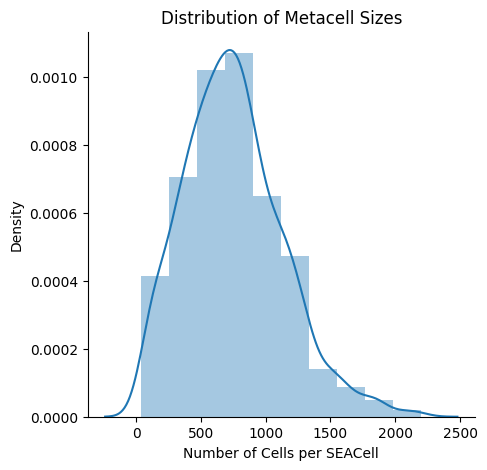

,size
SEACell,
SEACell-0,651
SEACell-1,727
SEACell-10,947
SEACell-100,659
SEACell-1000,661
...,...
SEACell-995,1052
SEACell-996,1128
SEACell-997,461


In [32]:
SEACells.plot.plot_SEACell_sizes(combined_adata_raw, bins=10)


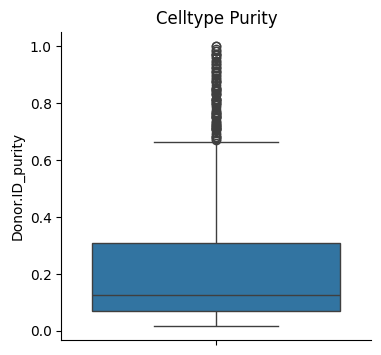

,Donor.ID,Donor.ID_purity
SEACell,,
SEACell-0,H20.33.029,0.044547
SEACell-1,ROSMAP-31874,0.111417
SEACell-10,ROSMAP-32462,0.073918
SEACell-100,H21.33.016,0.109256
SEACell-1000,NPH_1056,0.177005


In [34]:
import seaborn as sns 

SEACell_purity = SEACells.evaluate.compute_celltype_purity(combined_adata_raw, 'Donor.ID')

plt.figure(figsize=(4,4))
sns.boxplot(data=SEACell_purity, y='Donor.ID_purity')
plt.title('Celltype Purity')
sns.despine()
plt.show()
plt.close()

SEACell_purity.head()

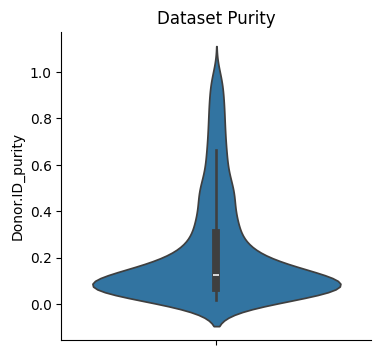

,Donor.ID,Donor.ID_purity
SEACell,,
SEACell-0,H20.33.029,0.044547
SEACell-1,ROSMAP-31874,0.111417
SEACell-10,ROSMAP-32462,0.073918
SEACell-100,H21.33.016,0.109256
SEACell-1000,NPH_1056,0.177005


In [35]:
SEACell_purity = SEACells.evaluate.compute_celltype_purity(combined_adata_raw, 'Donor.ID')

plt.figure(figsize=(4,4))
sns.violinplot(data=SEACell_purity, y='Donor.ID_purity')
plt.title('Dataset Purity')
sns.despine()
plt.show()
plt.close()

SEACell_purity.head()

In [18]:
combined_adata_proc.obs['SEACell'] = combined_adata.obs['SEACell'].copy()

In [37]:
SEACell_ad.obs['celltype'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: x['original_annotation'].mode().iloc[0]).loc[SEACell_ad.obs_names]
SEACell_ad.obs['# Distinct Donors'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: len(x['Donor.ID'].unique())).loc[SEACell_ad.obs_names]
SEACell_ad.obs['# Distinct Datasets'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: len(x['dataset'].unique())).loc[SEACell_ad.obs_names]
SEACell_ad.obs['No_SEAAD_cells'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: (x['dataset'] == 'SEAAD_pfc').sum()).loc[SEACell_ad.obs_names]
SEACell_ad.obs['No_101010_cells'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: (x['dataset'] == '101010_pfc').sum()).loc[SEACell_ad.obs_names]
SEACell_ad.obs['No_Gaz_cells'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: (x['dataset'] == 'gaz_pfc').sum()).loc[SEACell_ad.obs_names]
SEACell_ad.obs['No_Mathys_cells'] = combined_adata_proc.obs.groupby('SEACell').apply(lambda x: (x['dataset'] == 'mathys_pfc').sum()).loc[SEACell_ad.obs_names]


SEACell_ad.obs.head()


,celltype,# Distinct Donors,# Distinct Datasets,No_SEAAD_cells,No_101010_cells,No_Gaz_cells,No_Mathys_cells
SEACell-512,L2/3 IT_1,106,4,420,17,91,172
SEACell-528,L2/3 IT_1,72,4,638,85,115,151
SEACell-987,Exc L3-4 RORB CUX2,144,4,154,21,321,316
SEACell-405,Exc L2-3 CBLN2 LINC02306,131,4,209,15,41,756
SEACell-954,L2/3 IT_1,81,4,397,5,37,176


In [11]:
path_1010102 = pd.read_csv('/staging/leuven/stg_00079/projects/Magda/analysis/NDC/00.Preanalysis/all_layers_mean_pathology_values.csv')

In [16]:
combined_adata.obs = pd.merge(left = combined_adata.obs, right = path_1010102, left_on = 'Donor.ID', right_on = 'slice_id', how = 'outer')

/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/anndata/_core/anndata.py:788: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


In [98]:
combined_adata.obs.index = combined_adata.obs['barcode'].copy()

In [99]:
combined_adata.obs = combined_adata.obs.reindex(combined_adata_seacells.obs.index)

if combined_adata.obs.index.equals(combined_adata_seacells.obs.index):
    print("Indices are now aligned.")
else:
    print("Indices are still not aligned. Please check.")


Indices are now aligned.


In [80]:
SEACell_ad.write_h5ad('./TMP2_v2_seacellObj_combined_noRefOutliers_PFC_L23_allgenes_h5ad_20251124.h5ad')
